<font size=5>*Sentiment Prediction Model*

In [1]:
import pandas as pd
import numpy as np
import sys

if not sys.warnoptions:
    import warnings
    warnings.simplefilter("ignore")


In [2]:
# Loading the dataset
df = pd.read_csv('IMDB Dataset.csv')

In [3]:
# Checking the shape of the dataset
df.shape

(50000, 2)

In [4]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
df['review'][1]

'A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams\' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master\'s of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional \'dream\' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell\'s murals decorating every surface) are terribly well d

In [6]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [7]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [8]:
# Checking for null values
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [9]:
# Checking Duplicate
df.duplicated().sum()

418

In [10]:
# Removing Duplicate
df = df.drop_duplicates()

In [11]:
df.duplicated().sum()

0

In [12]:
df.shape

(49582, 2)

In [13]:
df['sentiment'].value_counts()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

In [14]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('wordnet')

stopword = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [15]:
def preprocessing(raw_text):
    # Lowercase
    text = raw_text.lower()
    
    # Removing Regular Expression
    text = re.sub(r"^'|'$", '', text)
    text = re.sub(r'[^A-Za-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenization
    text = word_tokenize(text)

    # Lemmatization
    clean_text = [lemmatizer.lemmatize(word) for word in text] 
    return " ".join(clean_text)

In [16]:
df['review'] = df['review'].apply(preprocessing)

In [17]:
df['review'].sample(5)

34248    this film wa so disappointing from the blurb t...
8829     while returning from a christmas eve shopping ...
32230    see dick work br br see jane work br br dick a...
17802    this movie ha remained in my mind for year a o...
43911    minute of this is cruel and i love the old mun...
Name: review, dtype: object

In [18]:
df.head()

,review,sentiment
0,one of the other reviewer ha mentioned that af...,positive
1,a wonderful little production br br the filmin...,positive
2,i thought this wa a wonderful way to spend tim...,positive
3,basically there s a family where a little boy ...,negative
4,petter mattei s love in the time of money is a...,positive


In [19]:
# Splitting Dataset
x = df['review']
y = df['sentiment'].map({'positive':1, 'negative':0})

In [20]:
x.head()

0    one of the other reviewer ha mentioned that af...
1    a wonderful little production br br the filmin...
2    i thought this wa a wonderful way to spend tim...
3    basically there s a family where a little boy ...
4    petter mattei s love in the time of money is a...
Name: review, dtype: object

In [21]:
y.head()

0    1
1    1
2    1
3    0
4    1
Name: sentiment, dtype: int64

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [23]:
X_train

7837     i really liked the movie the emporer s new gro...
4814     i decided to watch this movie because it ha be...
35458    it s very hard to say just what wa going on wi...
3446     this sci fi adventure is not the best and by n...
24478    around the late s animator don bluth frustrate...
                               ...                        
11304    dictated by thin experience of both life and i...
45059    this wa a classic case of something that shoul...
38405    spoiler spoiler br br i saw this movie last ni...
860      this production wa quite a surprise for me i a...
15838    this is a real eye candy a world made of float...
Name: review, Length: 39665, dtype: object

In [24]:
y_train

7837     0
4814     0
35458    1
3446     0
24478    0
        ..
11304    0
45059    0
38405    0
860      1
15838    1
Name: sentiment, Length: 39665, dtype: int64

In [25]:
# Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [105]:
# # Model Building
# from sklearn.svm import LinearSVC
# svm_model = LinearSVC()
# svm_model.fit(X_train_tfidf, y_train)

LinearSVC()

In [106]:
# # Model Prediction and Accuracy Score
# from sklearn.metrics import accuracy_score
# # Prediction
# y_pred = svm_model.predict(X_test_tfidf)

# # Accuracy Score
# print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.8934153473832812


In [28]:
# Model Building
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=100)
model.fit(X_train_tfidf, y_train)

LogisticRegression()

Accuracy: 0.8938186951699103


<Axes: >

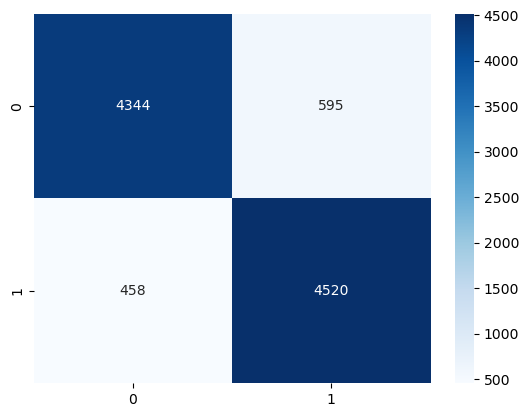

In [29]:
# Model Prediction and Accuracy Score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
# Prediction
y_pred = model.predict(X_test_tfidf)

# Accuracy Score
print('Accuracy:', accuracy_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

In [89]:
sample = "The movie was good"
clean = preprocessing(sample)
vector = tfidf.transform([clean])
print(model.predict(vector))

[1]


In [83]:
sample = "worst movie i have ever seen"
clean = preprocessing(sample)
vector = tfidf.transform([clean])
print(model.predict(vector))

[0]


In [103]:
sample = "The movie was not good"
clean = preprocessing(sample)
vector = tfidf.transform([clean])
print(model.predict(vector))

[0]
